###Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from itertools import combinations

###Hyper-Parameters

In [ ]:
BATCH_SIZE  = 128
EPOCHS = 40
LR = 1e-4
Z_DIM = 2
KL_MAX = 4.0

###Load Dataset MNIST

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32")  / 255.0

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test,  -1)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28, 1), Test: (10000, 28, 28, 1)


###

KL Annealing Callback

In [ ]:
class KLAnnealing(keras.callbacks.Callback):
    def __init__(self, vae_model, total_epochs, kl_max):
        super().__init__()
        self.vae_model = vae_model
        self.total_epochs = total_epochs
        self.kl_max = kl_max

    def on_epoch_begin(self, epoch, logs=None):
        # ramp from 0 to kl_max
        new_weight = self.kl_max * float(epoch) / float(self.total_epochs)
        self.vae_model.kl_weight.assign(new_weight)
        print(f"  [KL={new_weight:.3f}]", end="")

Reparameterization Layer

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        mu, log_var = inputs
        log_var = tf.clip_by_value(log_var, -4, 4)
        std = tf.exp(0.5 * log_var)
        eps = tf.random.normal(shape=tf.shape(mu))
        return mu + std * eps

###Encoder

In [ ]:
def build_encoder(z_dim):
    inputs = keras.Input(shape=(28, 28, 1), name="encoder_input")

    # Block 1: (28,28,1) -> (14,14,32)
    x = layers.Conv2D(32, 3, strides=1, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2: (14,14,32) -> (7,7,64)
    x = layers.Conv2D(64, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3: (7,7,64) -> (7,7,128)
    x = layers.Conv2D(128, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Flatten + two Dense bottlenecks
    x  = layers.Flatten()(x)
    x  = layers.Dense(256)(x)
    x  = layers.LeakyReLU(0.2)(x)
    x  = layers.Dense(128)(x)
    x  = layers.LeakyReLU(0.2)(x)

    mu = layers.Dense(z_dim, name="mu")(x)
    log_var = layers.Dense(z_dim, name="log_var")(x)
    z = Sampling()([mu, log_var])

    return keras.Model(inputs, [mu, log_var, z], name="encoder")

###Decoder

In [ ]:
def build_decoder(z_dim):
    inputs = keras.Input(shape=(z_dim,), name="decoder_input")

    # Expand z with two Dense layers
    x = layers.Dense(128)(inputs)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dense(7 * 7 * 128)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, 128))(x)

    # Block 1: (7,7,128) -> (7,7,128) refine
    x = layers.Conv2DTranspose(128, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Block 2: (7,7,128) -> (14,14,64)
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Block 3: (14,14,64) -> (14,14,64) refine
    x = layers.Conv2DTranspose(64, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Block 4: (14,14,64) -> (28,28,32)
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Block 5: (28,28,32) -> (28,28,32) refine  <- NEW, adds sharpness
    x = layers.Conv2DTranspose(32, 3, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    # Final output: (28,28,1)
    x = layers.Conv2DTranspose(1, 3, strides=1, padding="same", activation="sigmoid")(x)

    return keras.Model(inputs, x, name="decoder")

###VAE Model

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = tf.Variable(0.0, trainable=False, dtype=tf.float32)

        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker,
                self.recon_loss_tracker,
                self.kl_loss_tracker]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(data, training=True)
            x_recon = self.decoder(z,    training=True)

            # Reconstruction loss
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, x_recon),
                    axis=(1, 2)
                )
            )

            # KL Divergence
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + log_var - tf.square(mu) - tf.exp(log_var),
                    axis=1
                )
            )

            total_loss = recon_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "recon_loss": self.recon_loss_tracker.result(),
            "kl_loss":    self.kl_loss_tracker.result(),
        }

###Build and Train

In [ ]:
encoder = build_encoder(Z_DIM)
decoder = build_decoder(Z_DIM)

encoder.summary()
decoder.summary()

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LR))

kl_callback = KLAnnealing(vae, EPOCHS, KL_MAX)

lr_callback = keras.callbacks.ReduceLROnPlateau(
    monitor='total_loss', factor=0.5,
    patience=5, min_lr=1e-6,
    mode='min', verbose=1
)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 28, 28,    │        320 │ encoder_input[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 28, 28,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │      9,248 │ leaky_re_lu[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 14, 14,    │          0 │ leaky_re_lu_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 14, 14,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 7, 7, 64)  │     36,928 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 64)  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 7, 64)  │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 7, 7, 128) │          0 │ batch_normalizat

 Total params: 1,779,428 (6.79 MB)

 Trainable params: 1,778,788 (6.79 MB)

 Non-trainable params: 640 (2.50 KB)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6272)           │     1,611,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │         9,24

 Total params: 1,932,897 (7.37 MB)

 Trainable params: 1,932,257 (7.37 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[kl_callback, lr_callback],
    verbose=1
)

  [KL=0.000]Epoch 1/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - kl_loss: 216.4255 - recon_loss: 204.2973 - total_loss: 204.2973 - learning_rate: 1.0000e-04
  [KL=0.100]Epoch 2/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - kl_loss: 18.0723 - recon_loss: 158.6582 - total_loss: 160.4655 - learning_rate: 1.0000e-04
  [KL=0.200]Epoch 3/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - kl_loss: 11.3426 - recon_loss: 150.1414 - total_loss: 152.4099 - learning_rate: 1.0000e-04
  [KL=0.300]Epoch 4/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - kl_loss: 9.5812 - recon_loss: 147.2138 - total_loss: 150.0881 - learning_rate: 1.0000e-04
  [KL=0.400]Epoch 5/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - kl_loss: 8.5589 - recon_loss: 145.4408 - total_loss: 148.8643 - learning_rate: 1.0000e-04
  [KL=0.500]Epoch 6/40
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 7.8539 - recon_loss: 144.2664 - total_loss: 148.1933 - learning_rate: 1.0000e-04
  [KL=0.600]Epoch 7/40
469/469 ━━━━━━━━━━━━━━━━━━━

Training Loss Curve

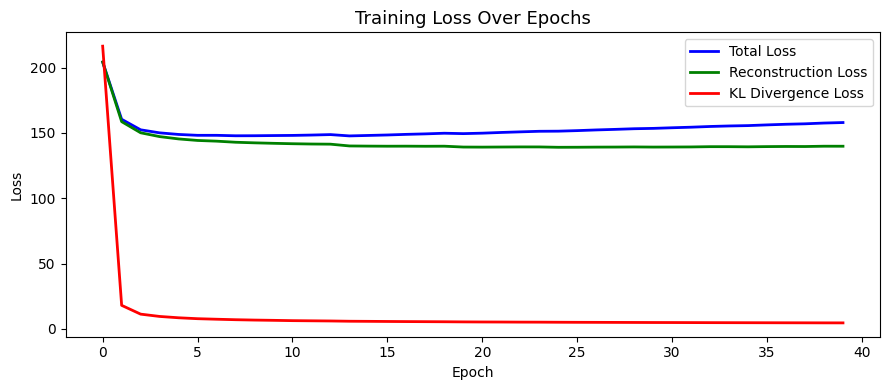

Saved: training_loss.png


In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(history.history['total_loss'], label='Total Loss', color='blue', linewidth=2)
plt.plot(history.history['recon_loss'], label='Reconstruction Loss', color='green', linewidth=2)
plt.plot(history.history['kl_loss'], label='KL Divergence Loss',  color='red', linewidth=2)
plt.title("Training Loss Over Epochs", fontsize=13)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: training_loss.png")

###Image Reconstruction

Original vs reconstructed images

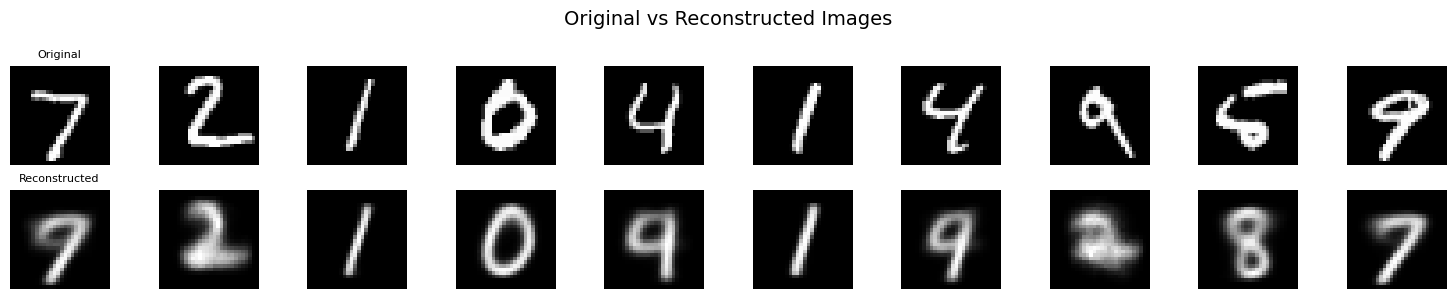

Saved: reconstruction.png


In [ ]:
test_sample = x_test[:10]
mu_out, _, z_out = encoder.predict(test_sample, verbose=0)
recon_images = decoder.predict(z_out, verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle("Original vs Reconstructed Images", fontsize=14)
for i in range(10):
    axes[0, i].imshow(test_sample[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Original",      fontsize=8)
    axes[1, i].imshow(recon_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("Reconstructed", fontsize=8)
plt.tight_layout()
plt.savefig("reconstruction.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reconstruction.png")

###New Sample Generation

Randomly Generated Samples

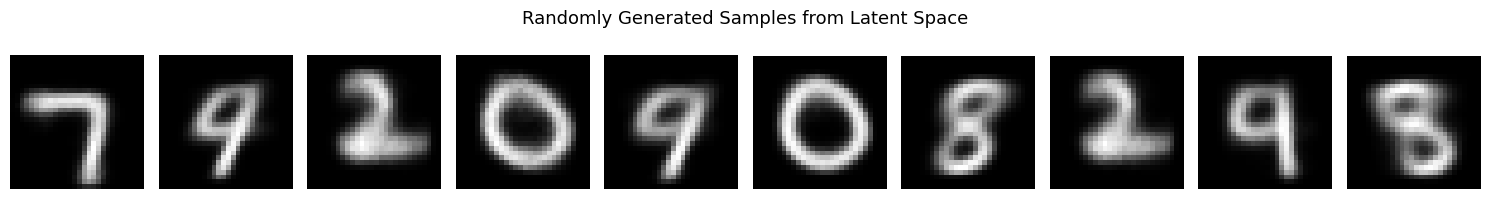

Saved: generated_samples.png


In [ ]:
np.random.seed(42)

# Sample z uniformly from the region where digits actually are
# We know from our latent space plot that clusters are within ~±2
random_z = np.random.uniform(low=-1.5, high=1.5,
                             size=(10, Z_DIM)).astype("float32")
gen_images = decoder.predict(random_z, verbose=0)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle("Randomly Generated Samples from Latent Space", fontsize=13)

for i in range(10):
    axes[i].imshow(gen_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("generated_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: generated_samples.png")

###Latent Space Visualization

In [ ]:
mu_test, _, z_test = encoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
recon_test = decoder.predict(z_test, batch_size=BATCH_SIZE, verbose=0)
mu_all_eval, _, _  = encoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

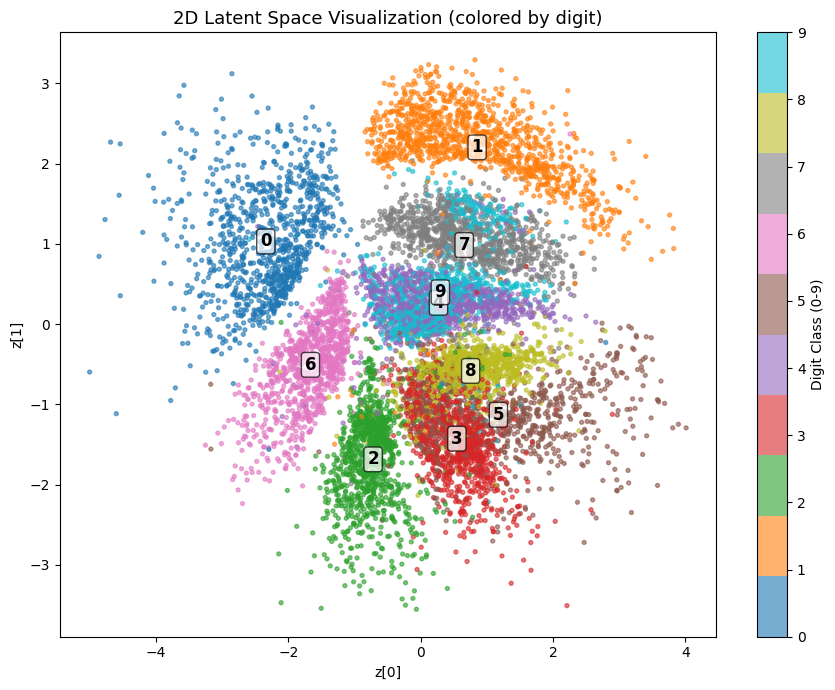

Saved: latent_space.png


In [ ]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    mu_all_eval[:, 0], mu_all_eval[:, 1],
    c=y_test, cmap='tab10', alpha=0.6, s=8
)
plt.colorbar(scatter, label='Digit Class (0-9)')

for digit in range(10):
    mask   = (y_test == digit)
    cx, cy = mu_all_eval[mask, 0].mean(), mu_all_eval[mask, 1].mean()
    plt.text(cx, cy, str(digit), fontsize=12, fontweight='bold',
             ha='center', va='center',
             bbox=dict(boxstyle='round,pad=0.2',
                       facecolor='white', alpha=0.7))

plt.title("2D Latent Space Visualization (colored by digit)", fontsize=13)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.tight_layout()
plt.savefig("latent_space.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: latent_space.png")

Latent Space Grid

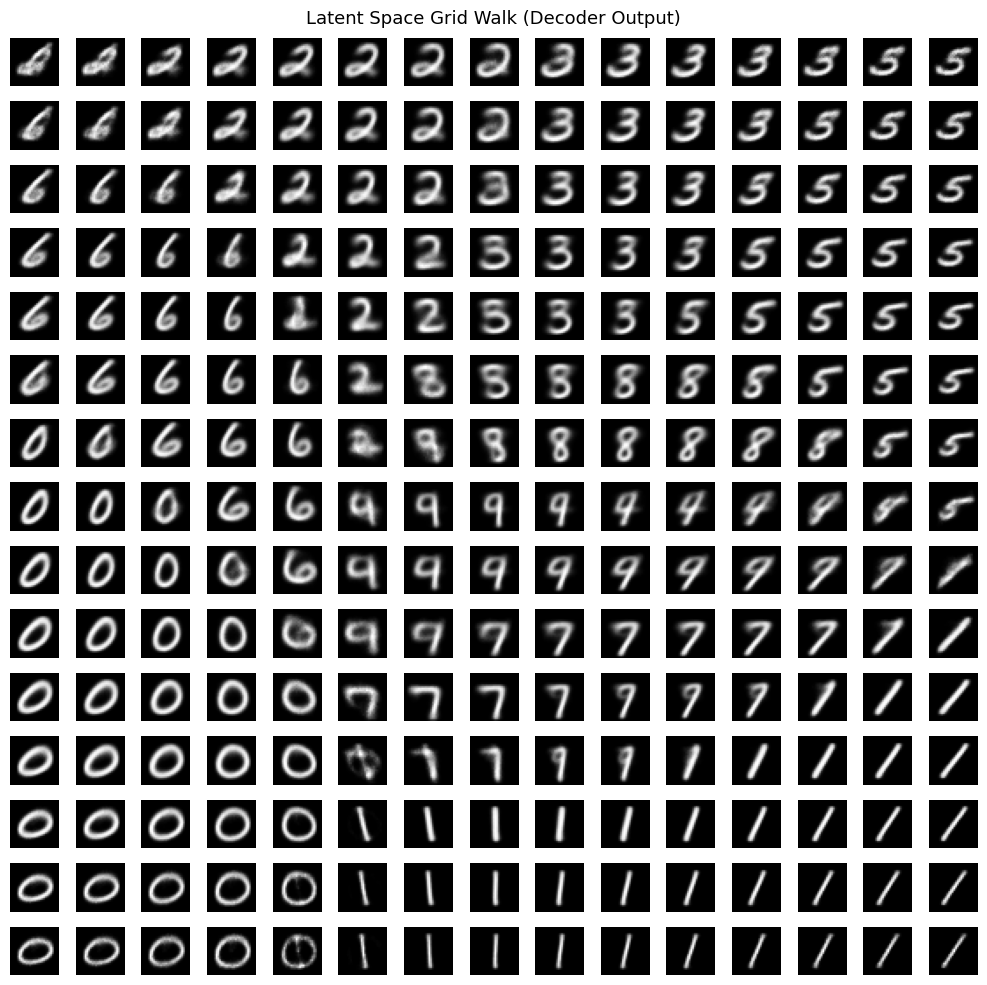

Saved: latent_grid_walk.png


In [ ]:
n = 15
grid = np.linspace(-3, 3, n)
fig, axes = plt.subplots(n, n, figsize=(10, 10))
fig.suptitle("Latent Space Grid Walk (Decoder Output)", fontsize=13)

for i, zi in enumerate(grid):
    for j, zj in enumerate(grid):
        z_pt = np.array([[zj, zi]], dtype="float32")
        img  = decoder.predict(z_pt, verbose=0)
        axes[i, j].imshow(img[0].squeeze(), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig("latent_grid_walk.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: latent_grid_walk.png")

###Evaluation Criteria

Reconstruction Loss

In [ ]:
mu_test, _, z_test = encoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
recon_test = decoder.predict(z_test, batch_size=BATCH_SIZE, verbose=0)

# pixel-wise BCE then sum per image then average over test set
bce = keras.losses.binary_crossentropy(x_test, recon_test)
recon_loss_val = float(np.mean(np.sum(bce, axis=(1, 2))))

print(f"Reconstruction Loss (BCE, avg per image): "f"{recon_loss_val:.2f}")

Reconstruction Loss (BCE, avg per image): 139.55


Reconstruction Loss — Bar chart per digit class

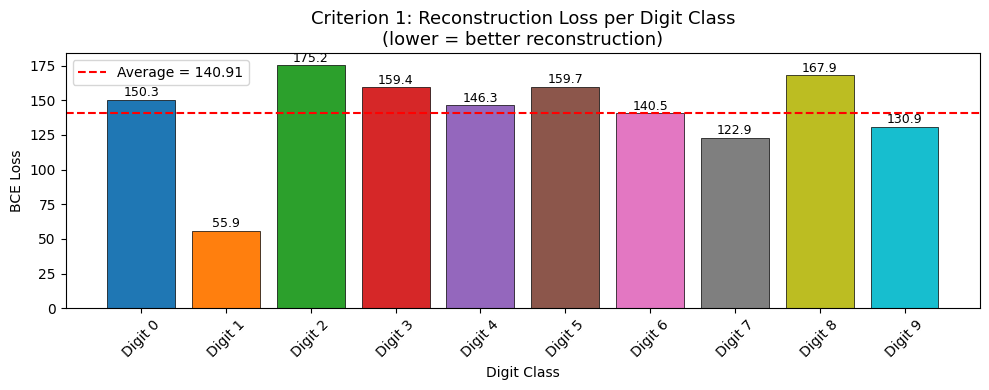

Saved: eval_reconstruction_loss.png


In [ ]:
digit_recon_losses = []

for digit in range(10):
    mask = (y_test == digit)
    x_d = x_test[mask]
    recon_d = recon_test[mask]
    bce_d = keras.losses.binary_crossentropy(x_d, recon_d)
    loss_d = float(np.mean(np.sum(bce_d, axis=(1, 2))))
    digit_recon_losses.append(loss_d)

overall_recon_loss = float(np.mean(digit_recon_losses))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(10), digit_recon_losses,
              color=plt.cm.tab10(np.linspace(0, 1, 10)),
              edgecolor='black', linewidth=0.5)

# Add value labels on top of each bar
for i, (bar, val) in enumerate(zip(bars, digit_recon_losses)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9)

ax.axhline(overall_recon_loss, color='red', linestyle='--',
           linewidth=1.5, label=f'Average = {overall_recon_loss:.2f}')
ax.set_xticks(range(10))
ax.set_xticklabels([f'Digit {i}' for i in range(10)], rotation=45)
ax.set_title('Criterion 1: Reconstruction Loss per Digit Class\n'
             '(lower = better reconstruction)', fontsize=13)
ax.set_ylabel('BCE Loss')
ax.set_xlabel('Digit Class')
ax.legend()
plt.tight_layout()
plt.savefig("eval_reconstruction_loss.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_reconstruction_loss.png")

Latent Space Continuity

In [ ]:
mu_all_eval, _, _ = encoder.predict(x_test, batch_size=BATCH_SIZE, verbose=0)

intra_stds = []
cluster_centers = []

for digit in range(10):
    mask = (y_test == digit)
    mu_digit = mu_all_eval[mask]
    intra_stds.append(mu_digit.std(axis=0).mean())
    cluster_centers.append(mu_digit.mean(axis=0))

cluster_centers = np.array(cluster_centers)  # shape (10, 2)
avg_intra_std = float(np.mean(intra_stds))

# average distance between all pairs of cluster centers
from itertools import combinations
inter_dists = []
for i, j in combinations(range(10), 2):
    dist = np.linalg.norm(cluster_centers[i] - cluster_centers[j])
    inter_dists.append(dist)
avg_inter_dist = float(np.mean(inter_dists))

continuity_ratio = avg_inter_dist / avg_intra_std

print(f"\nLatent Space Continuity:")
print(f"Avg intra-class std  (compactness) : {avg_intra_std:.3f}")
print(f"Avg inter-class dist (separation)  : {avg_inter_dist:.3f}")
print(f"Separation ratio (inter/intra)     : {continuity_ratio:.3f}")


Latent Space Continuity:
Avg intra-class std  (compactness) : 0.579
Avg inter-class dist (separation)  : 2.196
Separation ratio (inter/intra)     : 3.793


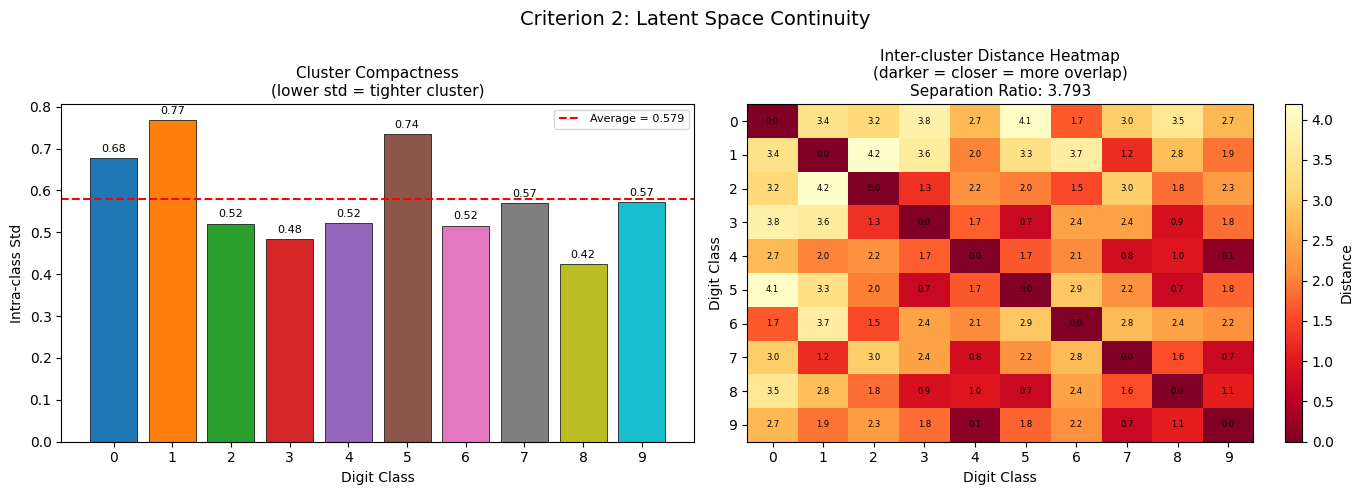

Saved: eval_latent_continuity.png


In [ ]:
intra_stds = []
cluster_centers = []

for digit in range(10):
    mask = (y_test == digit)
    mu_d = mu_all_eval[mask]
    intra_stds.append(mu_d.std(axis=0).mean())
    cluster_centers.append(mu_d.mean(axis=0))

cluster_centers = np.array(cluster_centers)
avg_intra_std = float(np.mean(intra_stds))

# Inter-cluster distance matrix
dist_matrix = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        dist_matrix[i, j] = np.linalg.norm(cluster_centers[i] - cluster_centers[j])

inter_dists = []
for i, j in combinations(range(10), 2):
    inter_dists.append(dist_matrix[i, j])
avg_inter_dist   = float(np.mean(inter_dists))
continuity_ratio = avg_inter_dist / avg_intra_std

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Criterion 2: Latent Space Continuity', fontsize=14)

# Left: Intra-class std bar chart (compactness)
axes[0].bar(range(10), intra_stds,
            color=plt.cm.tab10(np.linspace(0, 1, 10)),
            edgecolor='black', linewidth=0.5)
for i, val in enumerate(intra_stds):
    axes[0].text(i, val + 0.01, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=8)
axes[0].axhline(avg_intra_std, color='red', linestyle='--',
                linewidth=1.5, label=f'Average = {avg_intra_std:.3f}')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels([str(i) for i in range(10)])
axes[0].set_title('Cluster Compactness\n(lower std = tighter cluster)',
                  fontsize=11)
axes[0].set_ylabel('Intra-class Std')
axes[0].set_xlabel('Digit Class')
axes[0].legend(fontsize=8)

# Right: Inter-cluster distance heatmap
im = axes[1].imshow(dist_matrix, cmap='YlOrRd_r', aspect='auto')
plt.colorbar(im, ax=axes[1], label='Distance')
axes[1].set_xticks(range(10))
axes[1].set_yticks(range(10))
axes[1].set_xticklabels([str(i) for i in range(10)])
axes[1].set_yticklabels([str(i) for i in range(10)])
axes[1].set_title(f'Inter-cluster Distance Heatmap\n'
                  f'(darker = closer = more overlap)\n'
                  f'Separation Ratio: {continuity_ratio:.3f}',
                  fontsize=11)
axes[1].set_xlabel('Digit Class')
axes[1].set_ylabel('Digit Class')

# Add distance values in each cell
for i in range(10):
    for j in range(10):
        axes[1].text(j, i, f'{dist_matrix[i,j]:.1f}',
                     ha='center', va='center', fontsize=6,
                     color='black')

plt.tight_layout()
plt.savefig("eval_latent_continuity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_latent_continuity.png")

Quality of Generated Digits

In [ ]:
n_gen = 100
rand_z = np.random.normal(size=(n_gen, Z_DIM)).astype("float32")
gen_eval = decoder.predict(rand_z, batch_size=BATCH_SIZE, verbose=0)  # (100, 28, 28, 1)

gen_flat = gen_eval.squeeze()          # (100, 28, 28)

mean_bright = float(np.mean(gen_flat))
pixel_std = float(np.std(gen_flat))

# sharpness: average gradient magnitude across generated images
def sharpness(imgs):
    # imgs shape: (N, 28, 28)
    gy = np.diff(imgs, axis=1)   # vertical gradient
    gx = np.diff(imgs, axis=2)   # horizontal gradient
    return float(np.mean(np.abs(gy)) + np.mean(np.abs(gx)))

sharp_score = sharpness(gen_flat)

print(f"\nQuality of Generated Digits (from 100 random samples):")
print(f"Mean pixel brightness : {mean_bright:.4f}")
print(f"Pixel std (diversity) : {pixel_std:.4f}")
print(f"Sharpness score       : {sharp_score:.4f}")


Quality of Generated Digits (from 100 random samples):
Mean pixel brightness : 0.1274
Pixel std (diversity) : 0.2245
Sharpness score       : 0.0836


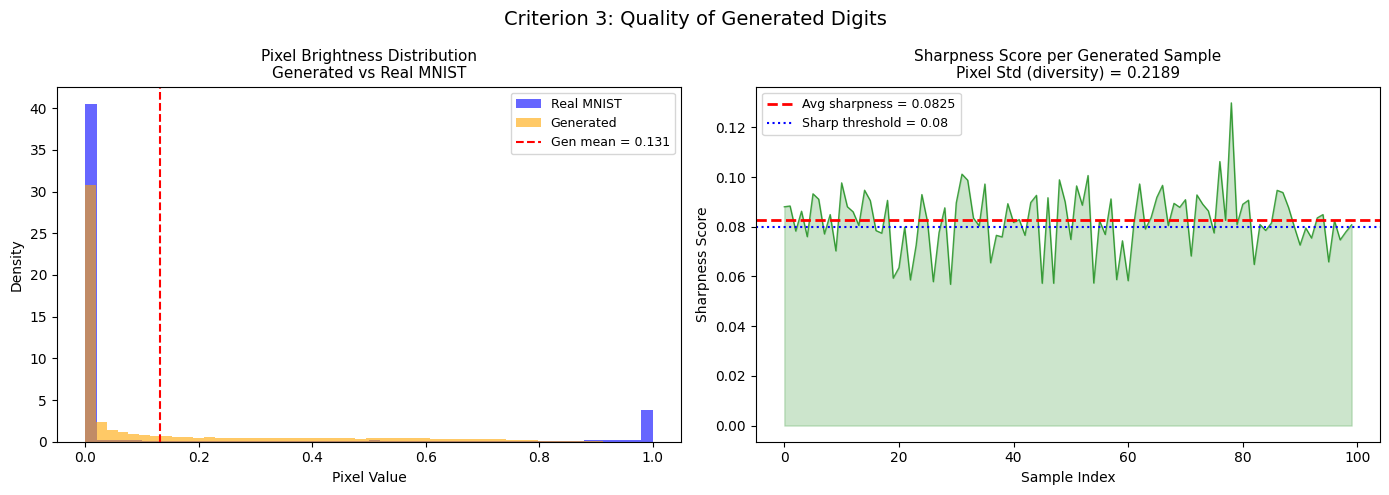

Saved: eval_generation_quality.png


In [ ]:
n_gen = 100
rand_z = np.random.uniform(-1.5, 1.5, size=(n_gen, Z_DIM)).astype("float32")
gen_eval = decoder.predict(rand_z, batch_size=BATCH_SIZE, verbose=0)
gen_flat = gen_eval.squeeze()   # (100, 28, 28)

# Sharpness per image
def sharpness_per_image(imgs):
    gy = np.diff(imgs, axis=1)
    gx = np.diff(imgs, axis=2)
    return np.mean(np.abs(gy), axis=(1,2)) + np.mean(np.abs(gx), axis=(1,2))

sharp_scores = sharpness_per_image(gen_flat)   # (100,)
avg_sharpness = float(np.mean(sharp_scores))
mean_bright = float(np.mean(gen_flat))
pixel_std = float(np.std(gen_flat))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Criterion 3: Quality of Generated Digits', fontsize=14)

# Left: Pixel brightness distribution — generated vs real
real_flat = x_test.squeeze().flatten()
gen_flat2 = gen_flat.flatten()

axes[0].hist(real_flat, bins=50, alpha=0.6, color='blue',
             label='Real MNIST', density=True)
axes[0].hist(gen_flat2, bins=50, alpha=0.6, color='orange',
             label='Generated', density=True)
axes[0].axvline(mean_bright, color='red', linestyle='--',
                label=f'Gen mean = {mean_bright:.3f}')
axes[0].set_title('Pixel Brightness Distribution\n'
                  'Generated vs Real MNIST', fontsize=11)
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Right: Sharpness score for each of the 100 generated images
axes[1].plot(sharp_scores, color='green', alpha=0.7, linewidth=1)
axes[1].axhline(avg_sharpness, color='red', linestyle='--',
                linewidth=2,
                label=f'Avg sharpness = {avg_sharpness:.4f}')
axes[1].axhline(0.08, color='blue', linestyle=':',
                linewidth=1.5, label='Sharp threshold = 0.08')
axes[1].fill_between(range(n_gen), sharp_scores,
                     alpha=0.2, color='green')
axes[1].set_title(f'Sharpness Score per Generated Sample\n'
                  f'Pixel Std (diversity) = {pixel_std:.4f}',
                  fontsize=11)
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Sharpness Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("eval_generation_quality.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eval_generation_quality.png")

Summary Table

In [ ]:
print("EVALUATION CRITERIA RESULTS:")
print(f"\n1. Reconstruction Loss (avg BCE) : {overall_recon_loss:.2f}")
print(f"\n2. Latent Space Continuity Ratio : {continuity_ratio:.3f}")
print(f"\n3. Generation Sharpness Score    : {avg_sharpness:.4f}")

EVALUATION CRITERIA RESULTS:

1. Reconstruction Loss (avg BCE) : 140.91

2. Latent Space Continuity Ratio : 3.793

3. Generation Sharpness Score    : 0.0825
